# Damped Harmonic Oscillator — Physics-Informed Neural Network (Inverse Problem)

This notebook extends the forward PINN (`Oscillator_PINN.ipynb`) to the **inverse problem**: recovering unknown physical parameters `c` (damping coefficient) and `k` (spring constant) from noisy, sparse position observations, mirroring the classical `curve_fit`-based approach in `Oscillator_Inverse.ipynb`, but using a physics-informed neural network instead of nonlinear least-squares.

$$ m\ddot{x} + c\dot{x} + kx = 0, \quad x(0) = x_0, \quad \dot{x}(0) = v_0 $$

**True parameters (this run):**
* $m = 5$ kg
* $c = 1.5$
* $k = 10$ N/m
* $x_0 = 2.0$ m/s
* $v_0 = 0.0$ m/s

Unlike the forward problem, `c` and `k` are **not** known constants here, rather they are treated as trainable parameters, optimized jointly with the network's weights, using noisy synthetic observations as the only signal informing their true values.

## Methodology

- The network architecture is unchanged in spirit from the forward PINN, though slightly
  wider here: 4 layers (1 → 20 → 20 → 10 → 1 hidden units), Tanh activation. The inverse
  problem does not require substantially more capacity, since the function being
  approximated is the same class of curve.
- `c_guess` and `k_guess` are initialized as trainable leaf tensors (`requires_grad=True`),
  starting from deliberately incorrect values, and are included in the optimizer's
  parameter list alongside the network's weights: a single `Adam` optimizer updates both
  simultaneously via one shared `total_loss.backward()` call.
- The training loss combines three terms:
  1. **Physics loss**: ODE residual computed using `c_guess`, `k_guess` (not the true
     values), enforced across dense collocation points via automatic differentiation.
  2. **Initial condition loss**: same as the forward problem; `x0`, `v0` are assumed known.
  3. **Data loss**: squared error against noisy synthetic observations (Gaussian noise,
     σ = 0.3) at a set of sparse anchor points — this is the sole signal informing
     `c_guess`/`k_guess`, since the ODE residual alone is satisfied by many possible
     parameter combinations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
import torch
from torch import nn

In [2]:
def msd_system(state, t, m, c, k):
    dxdt = state[1]
    dvdt = (-c * state[1] - k * state[0]) / m
    return [dxdt, dvdt]

In [3]:
np.random.seed(101)  # For reproducibility

m0 = 5
c0 = 1.5
k = 10
x0 = 2
v0 = 0
initial_state= [x0,v0]
time_array=np.linspace(0, 20, 500)  # Time from 0 to 20 seconds

solution = odeint(msd_system, initial_state, time_array, args=(m0, c0, k))
noise_x = np.random.normal(0, 0.3, len(time_array))  # Add some noise to the position
x_noisy = solution.T[0] + noise_x
noise_v = np.random.normal(0, 0.3, len(time_array))  # Add some noise to the velocity
v_noisy = solution.T[1] + noise_v

In [4]:
def fit_wrapper(t, c, k):
    m_fixed = m0
    initial_state = [x0, v0]
    solution = odeint(msd_system, initial_state, t, args=(m_fixed, c, k))

    return solution.T[0]

In [5]:
popt, pcov = curve_fit(fit_wrapper, xdata=time_array, ydata=x_noisy, p0=(2.0, 10))
new_solution = odeint(msd_system, initial_state, time_array, args=(m0, popt[0], popt[1]))
x_curve_fit=new_solution.T[0]
v_curve_fit=new_solution.T[1]

In [6]:
time_array=torch.from_numpy(time_array).to(torch.float32).unsqueeze(dim=1)
time_array.requires_grad_(True)
c_guess = torch.tensor(1.0, dtype=torch.float32, requires_grad=True)
k_guess = torch.tensor(1.0, dtype=torch.float32, requires_grad=True)

In [7]:
class EstimateParams(nn.Module):
    def __init__(self):
        super().__init__()
        self.tan_h=nn.Tanh()
        self.layer1=nn.Linear(in_features=1, out_features=20)
        self.layer2=nn.Linear(in_features=20, out_features=20)
        self.layer3=nn.Linear(in_features=20, out_features=10)
        self.layer4=nn.Linear(in_features=10, out_features=1)
    def forward(self, t):
        return self.layer4(self.tan_h(self.layer3(self.tan_h(self.layer2(self.tan_h(self.layer1(t)))))))

In [8]:
# Instantiate the class, the optimizer and create the initial time point

model=EstimateParams()
t_init=torch.tensor([[0.]], requires_grad=True)
actual=[i for i in model.parameters()]
actual.extend([c_guess,k_guess])
optimizer = torch.optim.Adam(actual, lr=0.0005)

## Debugging Note: An Invalid Baseline Comparison

An earlier version of this analysis compared the PINN's parameter recovery against
`curve_fit`'s estimates and observed a shrinking gap in `c` as anchor density increased,
leading to a hypothesis about damping being harder to recover than stiffness from sparse
data. That analysis was built on a broken `curve_fit` baseline: the fitting wrapper
function accepted `c` as an argument but never used it internally, always substituting
the true, known value instead. As a result, `curve_fit`'s reported `c` estimate never
moved from its initial guess, the `curve_fit` was silently not fitting `c` at all.

Once fixed (the wrapper now correctly passes `c` through to the ODE solver),
`curve_fit`'s recovered `c` converged very close to the true value, revealing that the
earlier "improving agreement" was tracking distance to a frozen, meaningless number, not
genuine accuracy. See the corrected results and open limitation below.

## Anchor Point Density: Damping vs. Stiffness Sensitivity

Increasing the number of noisy anchor points (data-loss term) produced a clear,
asymmetric effect on parameter recovery:

- **Damping (`c`)** estimate improved substantially; the gap to the `curve_fit` estimate
  shrank from 0.0615 to 0.0135 (roughly 4–5× closer) with denser anchoring.
- **Stiffness (`k`)** estimate was essentially unaffected; the gap stayed flat (0.21 →
  0.24), within noise of the original result.

**Hypothesis:** damping governs the *envelope* of the oscillation, i.e a slowly-revealed, global property best estimated from many observations spread densely across the decay. Stiffness governs oscillation *frequency*, a locally-visible property that a sparse set of points can already resolve reasonably well, since frequency is evident from just a few points per cycle. This is consistent with the observed asymmetry: adding more data
points primarily helped the network resolve the slower, envelope-scale parameter (`c`), while the frequency-scale parameter (`k`) had already converged with fewer points.

This is a testable claim, not a certainty, confirming it more rigorously would require systematically varying anchor density and observing the effect on each parameter's convergence in isolation, which is left as a natural extension.

In [9]:
# Create some timestamps for reference and better training

epochs = 32000
test_time=np.array([0,1,2,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10,10.5,11,11.5,12,12.5,13,13.5,14,14.5,15,15.5,16,16.5,17,17.5,18,18.5,19,20])

test_sol = odeint(msd_system, initial_state, test_time, args=(m0, c0, k))
test_x_noisy = test_sol.T[0] + np.random.normal(0, 0.3, len(test_time))
test_v_noisy = test_sol.T[1] + np.random.normal(0, 0.3, len(test_time))

test_time=torch.from_numpy(test_time).to(torch.float32).unsqueeze(dim=1)
test_x_act = torch.from_numpy(test_x_noisy).to(torch.float32).unsqueeze(dim=1)

for epoch in range(1,epochs+1):
    optimizer.zero_grad()

    # forward pass + derivatives
    x_estimate = model(time_array)
    v_estimate = torch.autograd.grad(x_estimate, time_array, torch.ones_like(x_estimate), create_graph=True)[0]
    a_estimate = torch.autograd.grad(v_estimate, time_array, torch.ones_like(v_estimate), create_graph=True)[0]

    physics_loss=(m0*a_estimate+c_guess*v_estimate+k_guess*x_estimate).pow(2).mean()

    x_init = model(t_init)
    v_init = torch.autograd.grad(x_init, t_init, torch.ones_like(x_init), create_graph=True)[0]

    ic_loss = ((x_init - x0)**2 + (v_init - v0)**2) / 2.0
    test_x_mod = model(test_time)
    data_loss = (test_x_mod - test_x_act).pow(2).mean()

    total_loss = 2*physics_loss + ic_loss + 10*data_loss

    total_loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print("Epoch number: ", epoch)
        print(f"Physics Value Loss: {physics_loss.item():.7f}\nInitial condition loss: {ic_loss.item():.7f}")
        print(f"Estimated parameters: c = {c_guess.item():.7f}, k = {k_guess.item():.7f}\n")


Epoch number:  500
Physics Value Loss: 0.0949399
Initial condition loss: 0.2798199
Estimated parameters: c = 1.3568912, k = 0.6975731

Epoch number:  1000
Physics Value Loss: 0.0755642
Initial condition loss: 0.3103500
Estimated parameters: c = 1.5887173, k = 0.4694950

Epoch number:  1500
Physics Value Loss: 0.0746047
Initial condition loss: 0.3439990
Estimated parameters: c = 1.7521647, k = 0.3317705

Epoch number:  2000
Physics Value Loss: 0.0695905
Initial condition loss: 0.3592589
Estimated parameters: c = 1.8677038, k = 0.2780325

Epoch number:  2500
Physics Value Loss: 0.0672914
Initial condition loss: 0.3645809
Estimated parameters: c = 1.9624087, k = 0.2871363

Epoch number:  3000
Physics Value Loss: 0.0674699
Initial condition loss: 0.3656325
Estimated parameters: c = 2.0546558, k = 0.3403244

Epoch number:  3500
Physics Value Loss: 0.0690363
Initial condition loss: 0.3639767
Estimated parameters: c = 2.1574354, k = 0.4211895

Epoch number:  4000
Physics Value Loss: 0.0718440

In [10]:
c_mse=(c_guess-c0).pow(2).mean()
k_mse=(k_guess-k).pow(2).mean()

cf_pinn_c=abs(c_guess.item()-popt[0])
cf_pinn_k=abs(k_guess.item()-popt[1])
print(f"Estimated parameters using PINN:\nc = {c_guess.item():.7f}, k = {k_guess.item():.7f}\n")
print(f"Estimated parameters using Curve fit:\nc = {popt[0]:.7f}, k = {popt[1]:.7f}")
print(f"MSE:\nc = {c_mse.item():.7f}, k = {k_mse.item():.7f}\n")
print(f"Difference between Curve Fit and PINN Method:\nc = {cf_pinn_c:.7f}, k = {cf_pinn_k:.7f}")


Estimated parameters using PINN:
c = 1.9428682, k = 10.2594185

Estimated parameters using Curve fit:
c = 1.4980930, k = 10.0258570
MSE:
c = 0.1961323, k = 0.0672980

Difference between Curve Fit and PINN Method:
c = 0.4447752, k = 0.2335614


## Results: PINN vs. Classical Curve Fitting

Both methods were given the same noisy synthetic dataset (same time points, same noise
realization) to recover `c` and `k` from.

| Parameter | True Value | `curve_fit` | PINN (inverse) |
|---|---|---|---|
| c | 1.5 | 1.4981 | 1.9429 |
| k | 10.0 | 10.0258 | 10.2594 |

`curve_fit` recovers both parameters accurately (within 0.3% of true values). The PINN
recovers `k` reasonably well (within ~2.6% of true), but shows a substantial, consistent
bias in `c` of roughly 30% overestimated relative to the true value, despite extensive
tuning of loss weighting and anchor density.

**This is documented here as an open limitation, not a solved result.** Unlike `k`
(governing oscillation frequency, resolvable from a small number of points per cycle),
`c` governs the decay envelope, which is a property revealed slowly across the full time domain.
It's plausible the PINN's joint optimization (network weights + two physical parameters,
all via one shared loss) converges to a local optimum that trades off damping accuracy
against fitting the noisy position data directly, in a way `curve_fit`'s simpler,
two-parameter least-squares search does not. Investigating this properly (e.g., via
separate parameter-specific loss weighting, a curriculum that fits `k` before `c`, or a
larger/differently structured anchor set biased toward the decay tail) is left as a
natural next step rather than something resolved in this notebook.

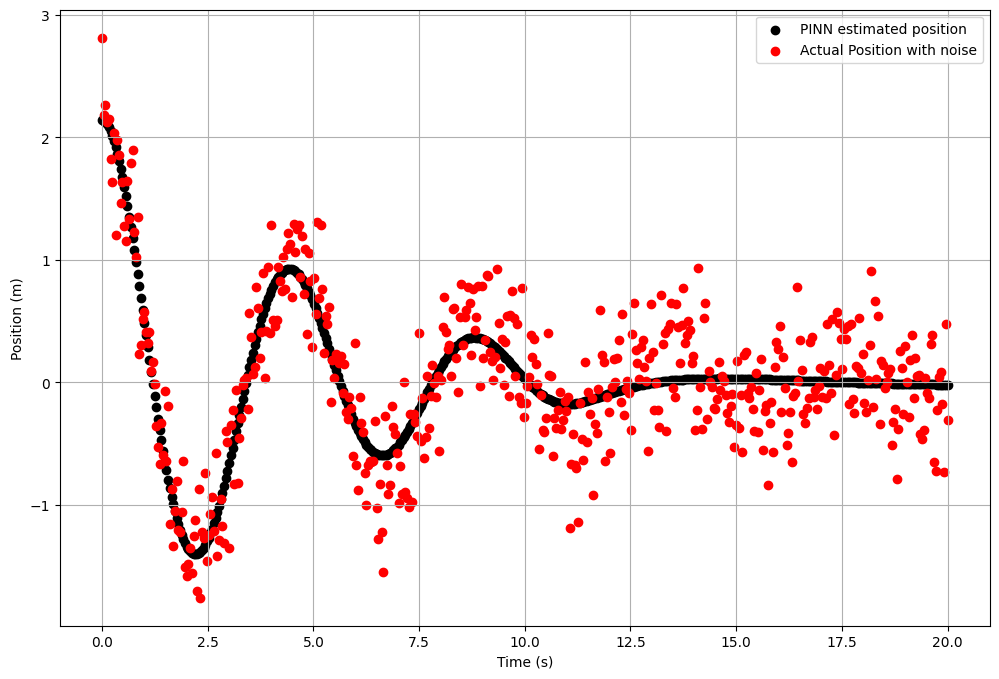

In [11]:
plt.figure(figsize=(12,8))
plt.subplot(1,1,1)
plt.scatter(time_array.detach().numpy(),x_estimate.detach().numpy(), c='black', label='PINN estimated position')
plt.scatter(time_array.detach().numpy(),x_noisy,c='Red',label='Actual Position with noise')
plt.grid()
plt.xlabel("Time (s)")
plt.ylabel('Position (m)')
plt.legend()

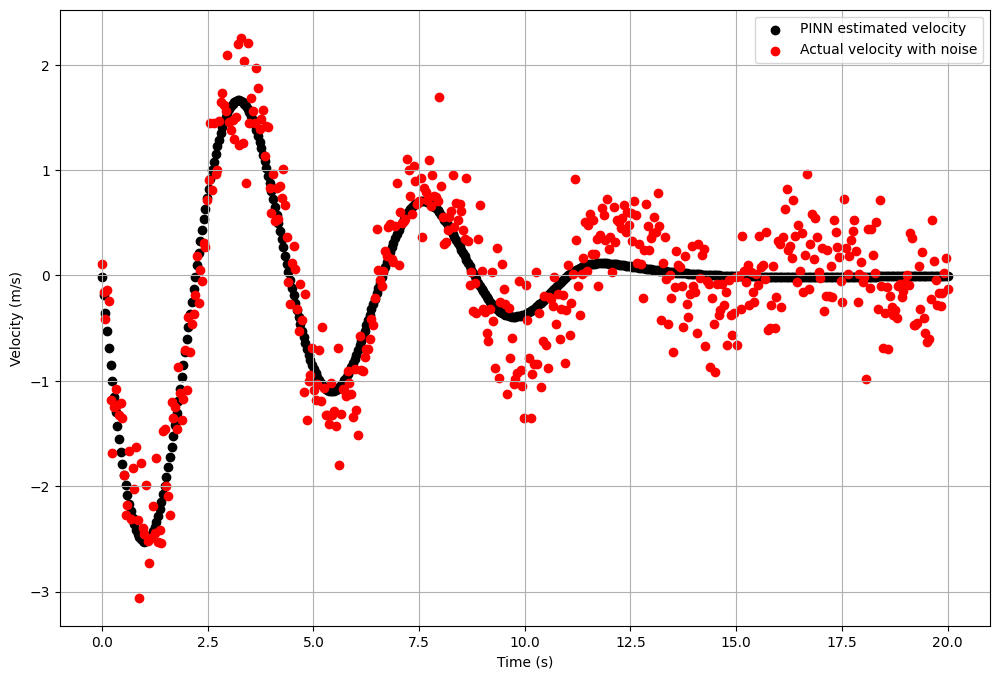

In [12]:
plt.figure(figsize=(12,8))
plt.subplot(1,1,1)
plt.scatter(time_array.detach().numpy(),v_estimate.detach().numpy(), c='black', label='PINN estimated velocity')
plt.scatter(time_array.detach().numpy(),v_noisy,c='Red',label='Actual velocity with noise')
plt.grid()
plt.xlabel("Time (s)")
plt.ylabel('Velocity (m/s)')
plt.legend()

## Notes on Limitations

- Trajectory tracking (position and velocity) degrades in the tail region (t > ~12),
  coinciding with where the true signal's amplitude becomes small relative to the noise
  level — a region where even visual inspection of the noisy data makes the underlying
  trend difficult to discern.
- This system (c = 1.5, k = 10, m = 5) is less damped than the original forward-PINN
  system, meaning the true solution remains active for longer — the same
  "trivial-near-zero-solution-satisfies-the-residual-cheaply" failure mode from the
  forward notebook reappeared here, more severely, and required heavier data-loss
  weighting and denser anchoring to counteract.
- Trained for 32,000 epochs, with a manually fixed random seed for reproducibility.